# Project: Identify Customer Segments

In this project, you will apply unsupervised learning techniques to identify segments of the population that form the core customer base for a mail-order sales company in Germany. These segments can then be used to direct marketing campaigns towards audiences that will have the highest expected rate of returns. The data that you will use has been provided by our partners at Bertelsmann Arvato Analytics, and represents a real-life data science task.

This notebook will help you complete this task by providing a framework within which you will perform your analysis steps. In each step of the project, you will see some text describing the subtask that you will perform, followed by one or more code cells for you to complete your work. **Feel free to add additional code and markdown cells as you go along so that you can explore everything in precise chunks.** The code cells provided in the base template will outline only the major tasks, and will usually not be enough to cover all of the minor tasks that comprise it.

It should be noted that while there will be precise guidelines on how you should handle certain tasks in the project, there will also be places where an exact specification is not provided. **There will be times in the project where you will need to make and justify your own decisions on how to treat the data.** These are places where there may not be only one way to handle the data. In real-life tasks, there may be many valid ways to approach an analysis task. One of the most important things you can do is clearly document your approach so that other scientists can understand the decisions you've made.

At the end of most sections, there will be a Markdown cell labeled **Discussion**. In these cells, you will report your findings for the completed section, as well as document the decisions that you made in your approach to each subtask. **Your project will be evaluated not just on the code used to complete the tasks outlined, but also your communication about your observations and conclusions at each stage.**

In [1]:
# import libraries here; add more as necessary
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# magic word for producing visualizations in notebook
%matplotlib inline

pd.options.display.max_rows = None
pd.options.display.max_columns = None

### Step 0: Load the Data

There are four files associated with this project (not including this one):

- `Udacity_AZDIAS_Subset.csv`: Demographics data for the general population of Germany; 891211 persons (rows) x 85 features (columns).
- `Udacity_CUSTOMERS_Subset.csv`: Demographics data for customers of a mail-order company; 191652 persons (rows) x 85 features (columns).
- `Data_Dictionary.md`: Detailed information file about the features in the provided datasets.
- `AZDIAS_Feature_Summary.csv`: Summary of feature attributes for demographics data; 85 features (rows) x 4 columns

Each row of the demographics files represents a single person, but also includes information outside of individuals, including information about their household, building, and neighborhood. You will use this information to cluster the general population into groups with similar demographic properties. Then, you will see how the people in the customers dataset fit into those created clusters. The hope here is that certain clusters are over-represented in the customers data, as compared to the general population; those over-represented clusters will be assumed to be part of the core userbase. This information can then be used for further applications, such as targeting for a marketing campaign.

To start off with, load in the demographics data for the general population into a pandas DataFrame, and do the same for the feature attributes summary. Note for all of the `.csv` data files in this project: they're semicolon (`;`) delimited, so you'll need an additional argument in your [`read_csv()`](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.read_csv.html) call to read in the data properly. Also, considering the size of the main dataset, it may take some time for it to load completely.

Once the dataset is loaded, it's recommended that you take a little bit of time just browsing the general structure of the dataset and feature summary file. You'll be getting deep into the innards of the cleaning in the first major step of the project, so gaining some general familiarity can help you get your bearings.

In [2]:
# Load in the general demographics data.
pd_general = pd.read_csv("data/Udacity_AZDIAS_Subset.csv", sep=";")
# Load in the feature summary file and store it to a variable
# named `feat_info`.
feat_info = pd.read_csv("data/AZDIAS_Feature_Summary.csv", sep=";")


In [3]:
print("General Demographics")
print(f"Shape: {pd_general.shape[0]} rows  x {pd_general.shape[1]} columns")

print("\nSummary Feature")
print(f"Shape: {feat_info.shape[0]} rows x {feat_info.shape[1]} columns")

General Demographics
Shape: 891221 rows  x 85 columns

Summary Feature
Shape: 85 rows x 4 columns


In [4]:
print("General Rows", pd_general.head(4))
print("General Data types", pd_general.dtypes)
print("Summary Rows",feat_info.head(4))

General Rows    AGER_TYP  ALTERSKATEGORIE_GROB  ANREDE_KZ  CJT_GESAMTTYP  \
0        -1                     2          1            2.0   
1        -1                     1          2            5.0   
2        -1                     3          2            3.0   
3         2                     4          2            2.0   

   FINANZ_MINIMALIST  FINANZ_SPARER  FINANZ_VORSORGER  FINANZ_ANLEGER  \
0                  3              4                 3               5   
1                  1              5                 2               5   
2                  1              4                 1               2   
3                  4              2                 5               2   

   FINANZ_UNAUFFAELLIGER  FINANZ_HAUSBAUER  FINANZTYP  GEBURTSJAHR  \
0                      5                 3          4            0   
1                      4                 5          1         1996   
2                      3                 5          1         1979   
3                      1 

In [5]:
pd_general.info()

<class 'pandas.DataFrame'>
RangeIndex: 891221 entries, 0 to 891220
Data columns (total 85 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   AGER_TYP               891221 non-null  int64  
 1   ALTERSKATEGORIE_GROB   891221 non-null  int64  
 2   ANREDE_KZ              891221 non-null  int64  
 3   CJT_GESAMTTYP          886367 non-null  float64
 4   FINANZ_MINIMALIST      891221 non-null  int64  
 5   FINANZ_SPARER          891221 non-null  int64  
 6   FINANZ_VORSORGER       891221 non-null  int64  
 7   FINANZ_ANLEGER         891221 non-null  int64  
 8   FINANZ_UNAUFFAELLIGER  891221 non-null  int64  
 9   FINANZ_HAUSBAUER       891221 non-null  int64  
 10  FINANZTYP              891221 non-null  int64  
 11  GEBURTSJAHR            891221 non-null  int64  
 12  GFK_URLAUBERTYP        886367 non-null  float64
 13  GREEN_AVANTGARDE       891221 non-null  int64  
 14  HEALTH_TYP             891221 non-null  int64  

In [6]:
pd_general.describe()

,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GEBURTSJAHR,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,PRAEGENDE_JUGENDJAHRE,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,TITEL_KZ,VERS_TYP,ZABEOTYP,ALTER_HH,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,KK_KUNDENTYP,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,WOHNLAGE,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_BAUMAX,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
count,891221.000000,891221.000000,891221.000000,886367.000000,891221.000000,891221.000000,891221.000000,891221.000000,891221.000000,891221.000000,891221.000000,891221.000000,886367.000000,891221.000000,891221.000000,886367.000000,886367.000000,886367.000000,886367.000000,886367.000000,886367.000000,891221.000000,891221.000000,886367.000000,891221.000000,891221.000000,891221.000000,891221.000000,891221.000000,891221.000000,891221.000000,891221.000000,891221.000000,891221.000000,891221.000000,891221.000000,891221.000000,891221.000000,891221.000000,817722.000000,817722.000000,891221.000000,891221.000000,817722.000000,817722.000000,817722.000000,872873.000000,306609.000000,783619.000000,817722.000000,798073.000000,794213.000000,798073.000000,817252.000000,798073.000000,798073.000000,757897.000000,757897.000000,757897.000000,757897.000000,757897.000000,757897.000000,797481.000000,797481.000000,797481.000000,798066.000000,770025.000000,757897.000000,886367.000000,770025.000000,785421.000000,774706.000000,774706.000000,774706.000000,774706.000000,774706.000000,774706.000000,774706.000000,794005.000000,794005.000000,794005.00000
mean,-0.358435,2.777398,1.522098,3.632838,3.074528,2.821039,3.401106,3.033328,2.874167,3.075121,3.790586,1101.178533,7.350304,0.196612,1.792102,14.622637,4.453621,3.599574,2.185966,4.791151,2.432575,1.026827,8.154346,3.419630,3.945860,4.272729,4.240609,4.001597,4.023709,4.359086,4.481405,4.025014,3.910139,4.763223,4.667550,4.445007,4.256076,3.661784,1.266967,0.008423,0.003483,1.197852,3.362438,10.864126,1.727637,0.004162,4.207243,3.410640,3.933406,7.908791,8.287263,0.040647,2.798641,3.018452,1993.277011,4.052836,1.494277,1.265584,0.624525,0.305927,1.389552,3.158580,4.153043,3.939172,4.549491,3.738306,2.592991,2.963540,2.698691,4.257967,619.701439,2.253330,2.801858,1.595426,0.699166,1.943913,3.612821,3.381087,3.167854,5.293002,3.07222
std,1.198724,1.068775,0.499512,1.595021,1.321055,1.464749,1.322134,1.529603,1.486731,1.353248,1.987876,976.583551,3.525723,0.397437,1.269062,12.616883,3.855639,3.926486,1.756537,3.425305,1.474315,0.586634,4.844532,1.417741,1.946564,1.915885,2.007373,1.857540,2.077746,2.022829,1.807552,1.903816,1.580306,1.830789,1.795712,1.852412,1.770137,1.707637,1.287435,0.091392,0.084957,0.952532,1.352704,7.639683,1.155849,0.068855,1.624057,1.628844,1.964701,1.923137,15.628087,0.324028,2.656713,1.550312,3.332739,1.949539,1.403961,1.245178,1.013443,0.638725,1.779483,1.329537,2.183710,1.718996,2.028919,0.923193,1.119052,1.428882,1.521524,2.030385,340.034318,0.972008,0.920309,0.986736,0.727137,1.459654,0.973967,1.111598,1.002376,2.303739,1.36298
min,-1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000

### Percentage of missing values in each column

In [7]:
native_missing_pct = (pd_general.isnull().sum() / len(pd_general) * 100).sort_values(ascending=False)
native_missing_pct.head(20)

KK_KUNDENTYP        65.596749
KBA05_BAUMAX        14.959701
KBA05_ANTG2         14.959701
MOBI_REGIO          14.959701
KBA05_GBZ           14.959701
KBA05_ANTG1         14.959701
KBA05_ANTG4         14.959701
KBA05_ANTG3         14.959701
KKK                 13.598872
REGIOTYP            13.598872
PLZ8_ANTG4          13.073637
PLZ8_HHZ            13.073637
PLZ8_ANTG2          13.073637
PLZ8_ANTG1          13.073637
PLZ8_ANTG3          13.073637
PLZ8_BAUMAX         13.073637
PLZ8_GBZ            13.073637
W_KEIT_KIND_HH      12.073549
KBA13_ANZAHL_PKW    11.871354
CAMEO_DEUG_2015     11.106000
dtype: float64

In [8]:
dup_mask = pd_general.duplicated(keep=False)
pd_general[dup_mask].sort_values(by=list(pd_general.columns)).head(10)

,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GEBURTSJAHR,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,PRAEGENDE_JUGENDJAHRE,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,TITEL_KZ,VERS_TYP,ZABEOTYP,ALTER_HH,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,KK_KUNDENTYP,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,WOHNLAGE,CAMEO_DEUG_2015,CAMEO_DEU_2015,CAMEO_INTL_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_BAUMAX,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
243112,-1,1,1,1.0,3,4,3,5,5,3,4,0,1.0,0,-1,6.0,2.0,1.0,1.0,1.0,1.0,0,0,5.0,2,6,7,5,1,5,3,3,4,7,6,6,5,3,-1,NaN,NaN,-1,3,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
523698,-1,1,1,1.0,3,4,3,5,5,3,4,0,1.0,0,-1,6.0,2.0,1.0,1.0,1.0,1.0,0,0,5.0,2,6,7,5,1,5,3,3,4,7,6,6,5,3,-1,NaN,NaN,-1,3,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
876954,-1,1,1,1.0,3,4,3,5,5,3,4,0,1.0,0,-1,6.0,2.0,1.0,1.0,1.0,1.0,0,0,5.0,2,6,7,5,1,5,3,3,4,7,6,6,5,3,-1,NaN,NaN,-1,3,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
329793,-1,1,1,1.0,3,4,3,5,5,3,4,0,1.0,0,-1,38.0,12.0,10.0,5.0,9.0,4.0,0,0,5.0,2,6,7,5,1,5,3,3,4,7,6,6,5,3,-1,NaN,NaN,-1,3,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
754263,-1,1,1,1.0,3,4,3,5,5,3,4,0,1.0,0,-1,38.0,12.0,10.0,5.0,9.0,4.0,0,0,5.0,2,6,7,5,1,5,3,3,4,7,6,6,5,3,-1,NaN,NaN,-1,3,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
439091,-1,1,1,1.0,3,4,3,5,5,3,4,0,1.0,0,-1,38.0,12.0,11.0,5.0,9.0,4.0,0,0,5.0,2,6,7,5,1,5,3,3,4,7,6,6,5,3,-1,NaN,NaN,-1,3,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
447136,-1,1,1,1.0,3,4,3,5,5,3,4,0,1.0,0,-1,38.0,12.0,11.0,5.0,9.0,4.0,0,0,5.0,2,6,7,5,1,5,3,3,4,7,6,6,5,3,-1,NaN,NaN,-1,3,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
318517,-1,1,1,1.0,3,4,3,5,5,3,4,0,1.0,0,-1,40.0,12.0,10.0,5.0,10.0,5.0,0,0,3.0,2,6,7,5,1,5,3,3,4,7,6,6,5,3,-1,NaN,NaN,-1,3,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
370931,-1,1,1,1.0,3,4,3,5,5,3,4,0,1.0,0,-1,40.0,12.0,10.0,5.0,10.0,5.0,0,0,3.0,2,6,7,5,1,5,3,3,4,7,6,6,5,3,-1,NaN,NaN,-1,3,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
568276,-1,1,1,1.0,3,4,3,5,5,3,4,0,3.0,0,-1,6.0,2.0,1.0,1.0,1.0,1.0,0,0,4.0,2,6,7,5,1,5,3,3,4,7,6,6,5,3,-1,NaN,NaN,-1,3,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 1: Preprocessing

### Step 1.1: Assess Missing Data

The feature summary file contains a summary of properties for each demographics data column. You will use this file to help you make cleaning decisions during this stage of the project. First of all, you should assess the demographics data in terms of missing data. Pay attention to the following points as you perform your analysis, and take notes on what you observe. Make sure that you fill in the **Discussion** cell with your findings and decisions at the end of each step that has one!

#### Step 1.1.1: Convert Missing Value Codes to NaNs
The fourth column of the feature attributes summary (loaded in above as `feat_info`) documents the codes from the data dictionary that indicate missing or unknown data. While the file encodes this as a list (e.g. `[-1,0]`), this will get read in as a string object. You'll need to do a little bit of parsing to make use of it to identify and clean the data. Convert data that matches a 'missing' or 'unknown' value code into a numpy NaN value. You might want to see how much data takes on a 'missing' or 'unknown' code, and how much data is naturally missing, as a point of interest.

**As one more reminder, you are encouraged to add additional cells to break up your analysis into manageable chunks.**

In [9]:
# Identify missing or unknown data values and convert them to NaNs.

feat_info.isnull().sum()


attribute             0
information_level     0
type                  0
missing_or_unknown    0
dtype: int64

In [10]:
print(feat_info.info())
print(feat_info.head())

<class 'pandas.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   attribute           85 non-null     str  
 1   information_level   85 non-null     str  
 2   type                85 non-null     str  
 3   missing_or_unknown  85 non-null     str  
dtypes: str(4)
memory usage: 5.5 KB
None
              attribute information_level         type missing_or_unknown
0              AGER_TYP            person  categorical             [-1,0]
1  ALTERSKATEGORIE_GROB            person      ordinal           [-1,0,9]
2             ANREDE_KZ            person  categorical             [-1,0]
3         CJT_GESAMTTYP            person  categorical                [0]
4     FINANZ_MINIMALIST            person      ordinal               [-1]


In [11]:
def parse_missing_codes(x):
    x = x.strip('[]')
    return [] if x == '' else x.split(',')

feat_info['missing_codes'] = feat_info['missing_or_unknown'].apply(parse_missing_codes)

In [12]:
native_missing = pd_general.isnull().sum()
pd_general_clean = pd_general.copy()
for _, rows in feat_info.iterrows():
    col = rows["attribute"]
    codes = rows['missing_codes']
    if not codes or col not in pd_general_clean.columns:
        continue
    if pd.api.types.is_numeric_dtype(pd_general_clean[col]):
        codes_cast = [int(c) for c in codes]
    else:
        codes_cast = codes
    pd_general_clean[col] = pd_general_clean[col].replace(codes_cast, np.nan)

total_missing_after = pd_general_clean.isnull().sum()
sentinel_added = total_missing_after - native_missing

print("sentinel_added\n", sentinel_added)

sentinel_added
 AGER_TYP                 685843
ALTERSKATEGORIE_GROB       2881
ANREDE_KZ                     0
CJT_GESAMTTYP                 0
FINANZ_MINIMALIST             0
FINANZ_SPARER                 0
FINANZ_VORSORGER              0
FINANZ_ANLEGER                0
FINANZ_UNAUFFAELLIGER         0
FINANZ_HAUSBAUER              0
FINANZTYP                     0
GEBURTSJAHR              392318
GFK_URLAUBERTYP               0
GREEN_AVANTGARDE              0
HEALTH_TYP               111196
LP_LEBENSPHASE_FEIN       92778
LP_LEBENSPHASE_GROB       89718
LP_FAMILIE_FEIN           72938
LP_FAMILIE_GROB           72938
LP_STATUS_FEIN                0
LP_STATUS_GROB                0
NATIONALITAET_KZ         108315
PRAEGENDE_JUGENDJAHRE    108164
RETOURTYP_BK_S                0
SEMIO_SOZ                     0
SEMIO_FAM                     0
SEMIO_REL                     0
SEMIO_MAT                     0
SEMIO_VERT                    0
SEMIO_LUST                    0
SEMIO_ERL               

Memory Reduction of the General Population Dataset for faster loading and processing.

In [13]:
def downcast_dataframe(df):
    df = df.copy()
    for col in df.columns:
        col_dtype = df[col].dtype
        if pd.api.types.is_float_dtype(col_dtype):
            df[col] = pd.to_numeric(df[col], downcast='float')
        elif pd.api.types.is_integer_dtype(col_dtype):
            df[col] = pd.to_numeric(df[col], downcast='integer')
        elif col_dtype == 'str' or col_dtype == object:
            df[col] = df[col].astype('category')
    return df

In [14]:
mem_before = pd_general_clean.memory_usage(deep=True).sum() / 1024**2
pd_general_small = downcast_dataframe(pd_general_clean)
mem_after = pd_general_small.memory_usage(deep=True).sum() / 1024**2

print(f'Before: {mem_before:.1f} MB')
print(f'After:  {mem_after:.1f} MB')
print(f'Reduction: {mem_before/mem_after:.1f}x')
print(pd_general_small.dtypes.value_counts())

Before: 582.9 MB
After:  217.6 MB
Reduction: 2.7x
float32     57
int8        24
category     1
category     1
category     1
category     1
Name: count, dtype: int64


#### Step 1.1.2: Assess Missing Data in Each Column

How much missing data is present in each column? There are a few columns that are outliers in terms of the proportion of values that are missing. You will want to use matplotlib's [`hist()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html) function to visualize the distribution of missing value counts to find these columns. Identify and document these columns. While some of these columns might have justifications for keeping or re-encoding the data, for this project you should just remove them from the dataframe. (Feel free to make remarks about these outlier columns in the discussion, however!)

For the remaining features, are there any patterns in which columns have, or share, missing data?

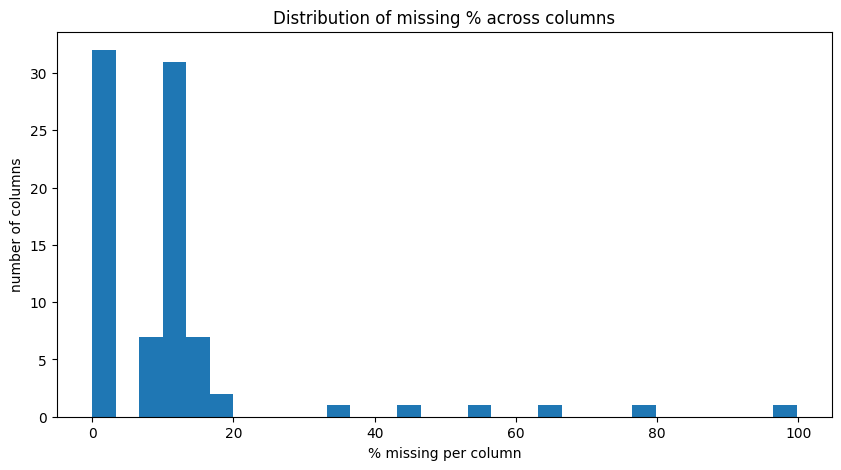

TITEL_KZ          99.757636
AGER_TYP          76.955435
KK_KUNDENTYP      65.596749
KBA05_BAUMAX      53.468668
GEBURTSJAHR       44.020282
ALTER_HH          34.813699
KKK               17.735668
REGIOTYP          17.735668
W_KEIT_KIND_HH    16.605084
KBA05_ANTG1       14.959701
KBA05_GBZ         14.959701
KBA05_ANTG2       14.959701
KBA05_ANTG3       14.959701
KBA05_ANTG4       14.959701
MOBI_REGIO        14.959701
PLZ8_ANTG2        13.073637
PLZ8_ANTG3        13.073637
PLZ8_BAUMAX       13.073637
PLZ8_ANTG4        13.073637
PLZ8_HHZ          13.073637
dtype: float64

In [15]:
# Perform an assessment of how much missing data there is in each column of the
# dataset.

missing_by_col = pd_general_clean.isnull().sum()
missing_pct_by_col = (missing_by_col / len(pd_general_clean) * 100).sort_values(ascending=False)

plt.figure(figsize=(10,5))
plt.hist(missing_pct_by_col, bins=30)
plt.xlabel('% missing per column')
plt.ylabel('number of columns')
plt.title('Distribution of missing % across columns')
plt.show()

missing_pct_by_col.head(20)

In [16]:
# Investigate patterns in the amount of missing data in each column.

group1 = ['KBA05_ANTG1','KBA05_GBZ','KBA05_ANTG2','KBA05_ANTG3','KBA05_ANTG4','MOBI_REGIO']
group2 = ['PLZ8_ANTG2','PLZ8_ANTG3','PLZ8_BAUMAX','PLZ8_ANTG4','PLZ8_HHZ']

mask1 = pd_general_clean[group1].isnull()
mask2 = pd_general_clean[group2].isnull()

print(mask1.sum(axis=1).value_counts())   # 0 or 6 = perfectly shared missingness
print(mask2.sum(axis=1).value_counts())   # 0 or 5 = perfectly shared missingness

overlap = (mask1['MOBI_REGIO'] & mask2['PLZ8_HHZ']).sum()
print('rows missing in both groups:', overlap)

0    757897
6    133324
Name: count, dtype: int64
0    774706
5    116515
Name: count, dtype: int64
rows missing in both groups: 107066


In [17]:
# Remove the outlier columns from the dataset. (You'll perform other data
# engineering tasks such as re-encoding and imputation later.)

outlier_cols = ['TITEL_KZ', 'AGER_TYP', 'KK_KUNDENTYP', 'KBA05_BAUMAX', 'GEBURTSJAHR', 'ALTER_HH']
pd_general_clean = pd_general_clean.drop(columns=outlier_cols)

# verification
assert pd_general_clean.shape == (891221, 79)
assert all(c not in pd_general_clean.columns for c in outlier_cols)

#### Discussion 1.1.2: Assess Missing Data in Each Column

Are there any other patterns in missing values? 

Confirmed pattern — and it's a real, meaningful one:

Group 1 (KBA05_* + MOBI_REGIO, all tied at 14.96% missing): row-wise missing counts are only ever 0 or 6 — never partial. That means these 6 columns are missing in exactly the same 133,324 rows. This isn't coincidence; it's one underlying cause producing all 6 gaps together.

Group 2 (PLZ8_*, tied at 13.07% missing): same story — missing counts are only ever 0 or 5, shared across 116,515 rows.

Cross-group overlap: 107,066 rows are missing in both groups, but 133,324 ≠ 116,515 ≠ 107,066, so they're not the same underlying cause — they overlap heavily but aren't identical.

What this means practically: KBA05_* are micro cell-level (RR4, smallest granularity) and PLZ8_* are macrocell-level (larger area). The likely real-world cause is a geocoding/address-matching failure — some records couldn't be matched down to the micro cell-level (missing KBA05_*), a distinct but overlapping set couldn't be matched to the macro cell-level (missing PLZ8_*), and a large chunk failed at both levels (the 107,066 overlap). This is structural missingness tied to geographic data availability, not random. 
The missing is because the person's address couldn't be geo-matched" rather than "person declined to answer."

Which columns were removed from the dataset?

The outlier columns that were removed from the dataset are:
TITEL_KZ          99.76%
AGER_TYP          76.96%
KK_KUNDENTYP      65.60%
KBA05_BAUMAX      53.47%
GEBURTSJAHR       44.02%
ALTER_HH          34.81%

These columns were removed based on the largest gap in missing percentages:
Looked for the largest gap between consecutive values, rather than picking a round-number cutoff. Computing the differences between adjacent sorted values:

99.76 → 76.96: gap of 22.8
76.96 → 65.60: gap of 11.4
65.60 → 53.47: gap of 12.1
53.47 → 44.02: gap of 9.5
44.02 → 34.81: gap of 9.2
34.81 → 17.74: gap of 17.1 ← largest gap in this region, and it's followed immediately by a cluster of columns bunched tightly together (17.74%, 17.74%, 16.61%, 14.96%×6, 13.07%×5...)

#### Step 1.1.3: Assess Missing Data in Each Row

Now, you'll perform a similar assessment for the rows of the dataset. How much data is missing in each row? As with the columns, you should see some groups of points that have a very different numbers of missing values. Divide the data into two subsets: one for data points that are above some threshold for missing values, and a second subset for points below that threshold.

In order to know what to do with the outlier rows, we should see if the distribution of data values on columns that are not missing data (or are missing very little data) are similar or different between the two groups. Select at least five of these columns and compare the distribution of values.
- You can use seaborn's [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) function to create a bar chart of code frequencies and matplotlib's [`subplot()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.subplot.html) function to put bar charts for the two subplots side by side.
- To reduce repeated code, you might want to write a function that can perform this comparison, taking as one of its arguments a column to be compared.

Depending on what you observe in your comparison, this will have implications on how you approach your conclusions later in the analysis. If the distributions of non-missing features look similar between the data with many missing values and the data with few or no missing values, then we could argue that simply dropping those points from the analysis won't present a major issue. On the other hand, if the data with many missing values looks very different from the data with few or no missing values, then we should make a note on those data as special. We'll revisit these data later on. **Either way, you should continue your analysis for now using just the subset of the data with few or no missing values.**

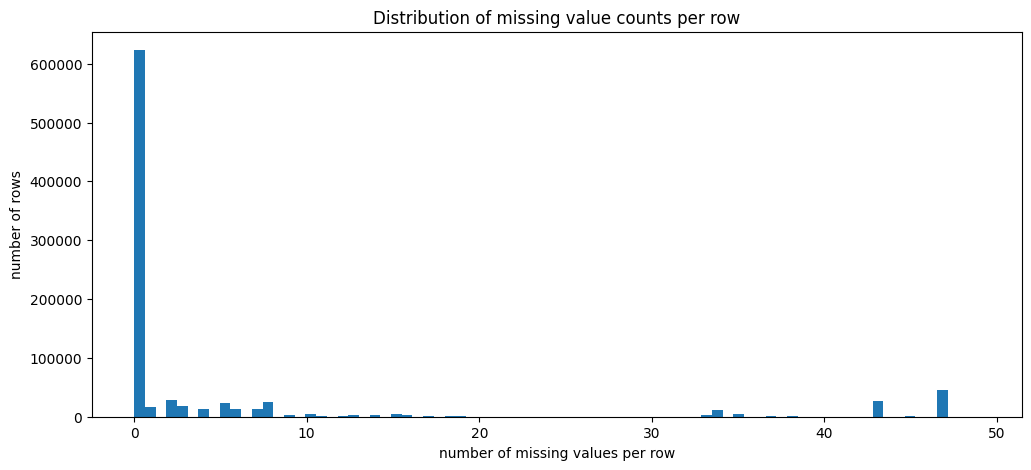

0     623209
1      15738
2      27926
3      17629
4      12607
5      22515
6      13771
7      13714
8      24592
9       3042
10      5410
11      1127
12       766
13      3255
14      2243
15      4743
16      2505
17       677
18       428
19      1180
20       349
21       150
22       129
23       132
24        69
25        55
26        59
27        24
28         5
29        12
30         6
31         3
32       206
33      2985
34     10816
35      3911
36        84
37       538
38       421
39        77
40       137
41       356
42        21
43     27369
44       155
45       494
47     45578
48         1
49         2
Name: count, dtype: int64

In [18]:
# How much data is missing in each row of the dataset?
row_missing_count = pd_general_clean.isnull().sum(axis=1)

plt.figure(figsize=(12,5))
plt.hist(row_missing_count, bins=79)
plt.xlabel('number of missing values per row')
plt.ylabel('number of rows')
plt.title('Distribution of missing value counts per row')
plt.show()

row_missing_count.value_counts().sort_index()

In [19]:
# Write code to divide the data into two subsets based on the number of missing
# values in each row.
threshold = 19
low_missing = pd_general_clean[row_missing_count <= threshold].copy()
high_missing = pd_general_clean[row_missing_count > threshold].copy()

# verification
assert len(low_missing) + len(high_missing) == len(pd_general_clean)
assert (low_missing.isnull().sum(axis=1) <= threshold).all()
assert (high_missing.isnull().sum(axis=1) > threshold).all()
print(f"Low Missing Values: {len(low_missing)}, High Missing Values: {len(high_missing)}")

Low Missing Values: 797077, High Missing Values: 94144


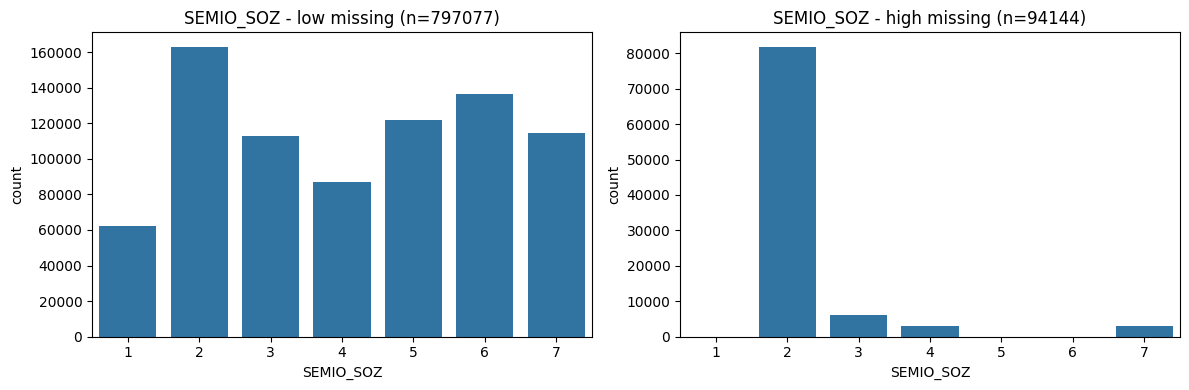

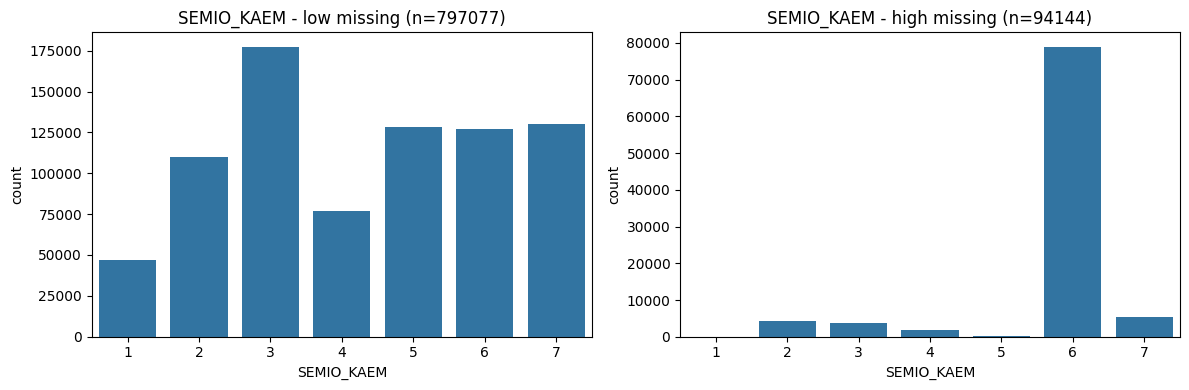

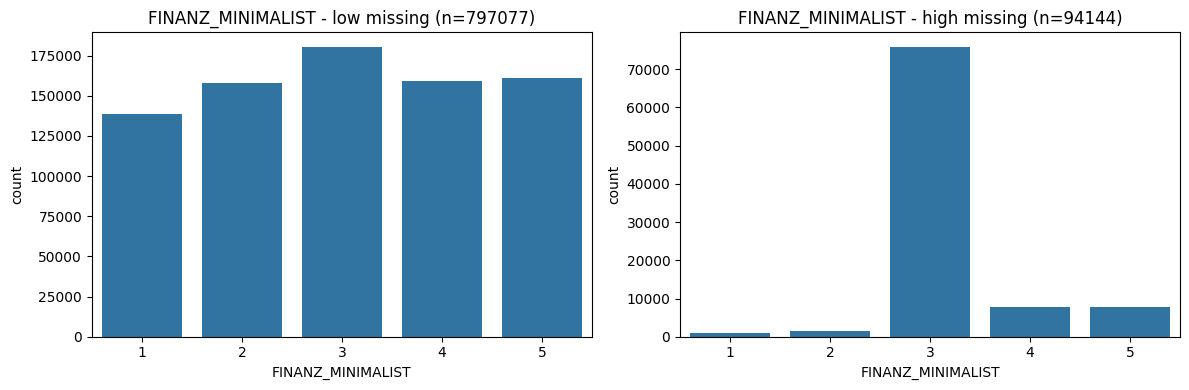

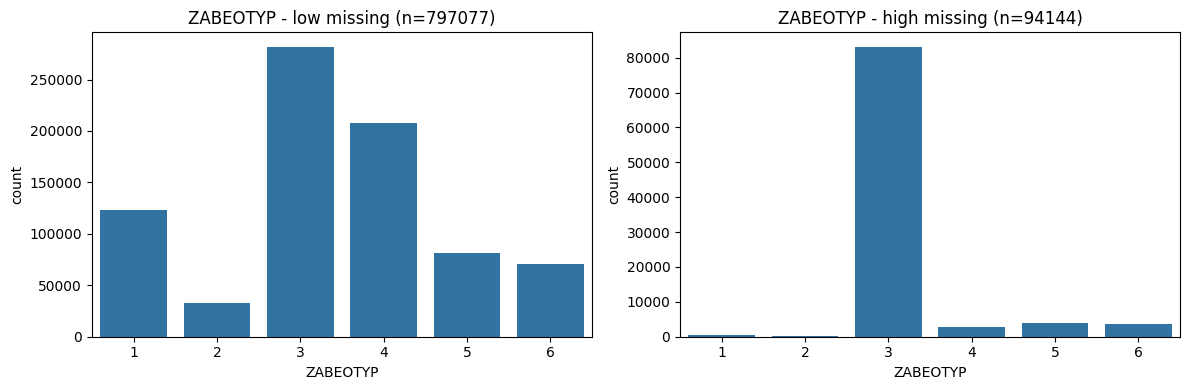

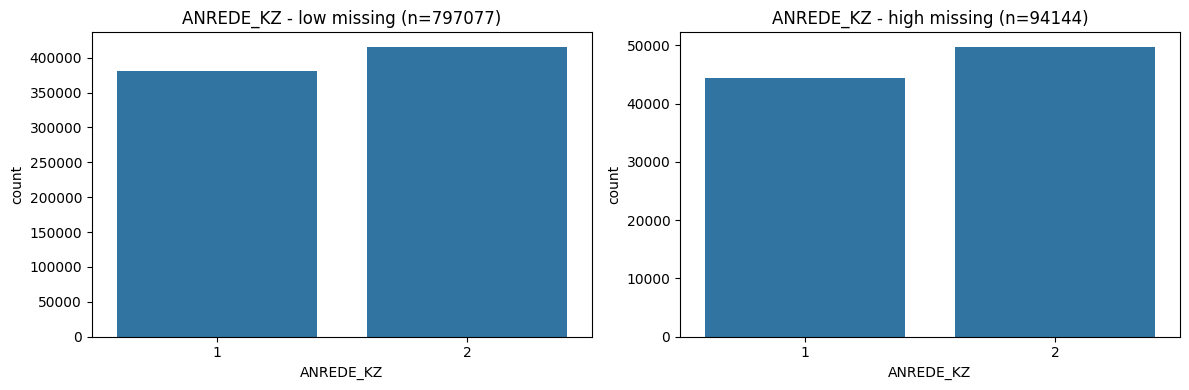

In [20]:
# Compare the distribution of values for at least five columns where there are
# no or few missing values, between the two subsets.
import seaborn as sns

def compare_col_distribution(col, low_df, high_df):
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    order = sorted(pd_general_clean[col].dropna().unique())
    sns.countplot(x=col, data=low_df, ax=axes[0], order=order)
    axes[0].set_title(f'{col} - low missing (n={len(low_df)})')
    sns.countplot(x=col, data=high_df, ax=axes[1], order=order)
    axes[1].set_title(f'{col} - high missing (n={len(high_df)})')
    plt.tight_layout()
    plt.show()

cols_to_compare = ['SEMIO_SOZ', 'SEMIO_KAEM', 'FINANZ_MINIMALIST', 'ZABEOTYP', 'ANREDE_KZ']
for c in cols_to_compare:
    assert pd_general_clean[c].isnull().sum() == 0, f'{c} is not actually a low/no-missing column'
    compare_col_distribution(c, low_missing, high_missing)

#### Discussion 1.1.3: Assess Missing Data in Each Row

4 of the 5 columns tested (SEMIO_SOZ, SEMIO_KAEM, FINANZ_MINIMALIST, ZABEOTYP), the two groups look nothing alike:

In low_missing, each of these columns is spread fairly evenly across its full range of valid codes (roughly 5-35% per category, no single value dominating).

In high_missing, one specific code absorbs 80-89% of the group (e.g. ZABEOTYP=3 at 88.3%, SEMIO_SOZ=2 at 86.9%). That's not a natural response distribution — it's the signature of a placeholder/default value being used when the real survey response was never collected. So even the columns that "aren't missing" for these rows contain values that are likely not meaningful.

The one exception was ANREDE_KZ (gender): 47-53% split in both groups, essentially identical — showing the effect isn't universal across every feature, just the behavioral/typology ones tested.

### Step 1.2: Select and Re-Encode Features

Checking for missing data isn't the only way in which you can prepare a dataset for analysis. Since the unsupervised learning techniques to be used will only work on data that is encoded numerically, you need to make a few encoding changes or additional assumptions to be able to make progress. In addition, while almost all of the values in the dataset are encoded using numbers, not all of them represent numeric values. Check the third column of the feature summary (`feat_info`) for a summary of types of measurement.
- For numeric and interval data, these features can be kept without changes.
- Most of the variables in the dataset are ordinal in nature. While ordinal values may technically be non-linear in spacing, make the simplifying assumption that the ordinal variables can be treated as being interval in nature (that is, kept without any changes).
- Special handling may be necessary for the remaining two variable types: categorical, and 'mixed'.

In the first two parts of this sub-step, you will perform an investigation of the categorical and mixed-type features and make a decision on each of them, whether you will keep, drop, or re-encode each. Then, in the last part, you will create a new data frame with only the selected and engineered columns.

Data wrangling is often the trickiest part of the data analysis process, and there's a lot of it to be done here. But stick with it: once you're done with this step, you'll be ready to get to the machine learning parts of the project!

In [21]:
# How many features are there of each data type?
remaining_cols = low_missing.columns.tolist()
feat_info_remaining = feat_info[feat_info['attribute'].isin(remaining_cols)]
feat_info_remaining['type'].value_counts()


type
ordinal        49
categorical    18
mixed           6
numeric         6
Name: count, dtype: int64

#### Step 1.2.1: Re-Encode Categorical Features

For categorical data, you would ordinarily need to encode the levels as dummy variables. Depending on the number of categories, perform one of the following:
- For binary (two-level) categoricals that take numeric values, you can keep them without needing to do anything.
- There is one binary variable that takes on non-numeric values. For this one, you need to re-encode the values as numbers or create a dummy variable.
- For multi-level categoricals (three or more values), you can choose to encode the values using multiple dummy variables (e.g. via [OneHotEncoder](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)), or (to keep things straightforward) just drop them from the analysis. As always, document your choices in the Discussion section.

In [22]:
# Assess categorical variables: which are binary, which are multi-level, and
# which one needs to be re-encoded?

cat_cols = feat_info[(feat_info['type']=='categorical') & (feat_info['attribute'].isin(low_missing.columns))]['attribute'].tolist()

cat_summary = pd.DataFrame({
    'n_unique': [low_missing[c].dropna().nunique() for c in cat_cols],
    'dtype': [low_missing[c].dtype for c in cat_cols]
}, index=cat_cols).sort_values('n_unique')

print(cat_summary)

                  n_unique    dtype
ANREDE_KZ                2    int64
GREEN_AVANTGARDE         2    int64
VERS_TYP                 2  float64
SOHO_KZ                  2  float64
OST_WEST_KZ              2      str
NATIONALITAET_KZ         3  float64
SHOPPER_TYP              4  float64
LP_FAMILIE_GROB          5  float64
LP_STATUS_GROB           5  float64
CJT_GESAMTTYP            6  float64
ZABEOTYP                 6    int64
FINANZTYP                6    int64
GEBAEUDETYP              7  float64
CAMEO_DEUG_2015          9      str
LP_STATUS_FEIN          10  float64
LP_FAMILIE_FEIN         11  float64
GFK_URLAUBERTYP         12  float64
CAMEO_DEU_2015          44      str


|Category	| Columns|
|----------|------------|
|Binary, numeric — keep as-is (4)	| ANREDE_KZ [1,2], GREEN_AVANTGARDE [0,1], SOHO_KZ [0,1], VERS_TYP [1,2]|
|Binary, non-numeric — needs re-encoding (1)	| OST_WEST_KZ — values 'O'/'W', exactly the one variable the instructions call out|
|Multi-level (3-44 levels) (13)	| NATIONALITAET_KZ(3), SHOPPER_TYP(4), LP_FAMILIE_GROB(5), LP_STATUS_GROB(5), CJT_GESAMTTYP(6), FINANZTYP(6), ZABEOTYP(6), GEBAEUDETYP(7), LP_STATUS_FEIN(10), LP_FAMILIE_FEIN(11), GFK_URLAUBERTYP(12), CAMEO_DEUG_2015(9), CAMEO_DEU_2015(44)|

LP_FAMILIE_FEIN/LP_STATUS_FEIN vs. their _GROB counterparts
- _FEIN is the fine-grained version, 
- _GROB the coarse version of the same underlying classification (family status, social status).

`One-hot encoding both means encoding the same information twice at different resolutions, adding redundant, collinear dummy columns going into PCA. 
_FEIN versions will be dropped and keep only _GROB, this action make it simpler and avoids duplicated signal.`

CAMEO_DEU_2015 (44 levels) — this is the fine-grained CAMEO segment, and CAMEO_DEUG_2015 (9 levels) is its coarser version — the same redundancy issue. One-hot encoding 44 categories also blows up dimensionality for comparatively little gain. I will drop CAMEO_DEU_2015, and keep CAMEO_DEUG_2015.

In [23]:
# Re-encode categorical variable(s) to be kept in the analysis.

# 1. Re-encode the one non-numeric binary variable
low_missing['OST_WEST_KZ'] = low_missing['OST_WEST_KZ'].map({'W': 1, 'O': 0})

# 2. Drop the redundant fine-grained duplicates before one-hot encoding
low_missing = low_missing.drop(columns=['LP_FAMILIE_FEIN', 'LP_STATUS_FEIN', 'CAMEO_DEU_2015'])

# 3. One-hot encode the remaining multi-level categoricals
multi_level_to_encode = ['CJT_GESAMTTYP', 'FINANZTYP', 'GFK_URLAUBERTYP', 'LP_FAMILIE_GROB',
                          'LP_STATUS_GROB', 'NATIONALITAET_KZ', 'SHOPPER_TYP', 'ZABEOTYP',
                          'GEBAEUDETYP', 'CAMEO_DEUG_2015']
low_missing = pd.get_dummies(low_missing, columns=multi_level_to_encode, dummy_na=False)

#### Discussion 1.2.1: Re-Encode Categorical Features

Of the 18 categorical features present after the row-missingness split, I kept 15 and dropped 3.

I kept unchanged (4 binary, numeric): `ANREDE_KZ, GREEN_AVANTGARDE, SOHO_KZ, VERS_TYP` - each already had exactly 2 numeric values, so no engineering was needed.

Re-encoded (1 binary, non-numeric): `OST_WEST_KZ` was the one categorical variable using non-numeric values ('W'/'O' for West/East Germany). Mapped directly to 1/0.

One-hot encoded (10 multi-level): `CJT_GESAMTTYP, FINANZTYP, GFK_URLAUBERTYP, LP_FAMILIE_GROB, LP_STATUS_GROB, NATIONALITAET_KZ, SHOPPER_TYP, ZABEOTYP, GEBAEUDETYP, CAMEO_DEUG_2015` — each expanded into one dummy column per category (63 new columns total), since these represent genuinely unordered categories (e.g. financial typology, building type) where imposing a numeric ordering would be a false assumption.

Dropped (3 columns), for redundancy rather than low value:

`LP_FAMILIE_FEIN` and `LP_STATUS_FEIN` — each is a finer-grained version of a _GROB counterpart already being one-hot encoded (LP_FAMILIE_GROB, LP_STATUS_GROB). Keeping both resolutions would duplicate the same underlying family/status signal across two sets of correlated dummy columns.

`CAMEO_DEU_2015` — confirmed to be `CAMEO_DEUG_2015` plus one additional sub-segment letter nested within each coarse group (verified directly against the data above). One-hot encoding both would encode the same wealth/lifestyle segmentation twice at different resolutions, and at 44 categories it would also disproportionately inflate dimensionality for information already captured by the 9-category `CAMEO_DEUG_2015`.

The net effect: 79 columns → 129 columns (63 new dummy columns, minus 3 dropped, minus 10 originals replaced by their dummy sets). The row count is unchanged at 797,077.

#### Step 1.2.2: Engineer Mixed-Type Features

There are a handful of features that are marked as "mixed" in the feature summary that require special treatment in order to be included in the analysis. There are two in particular that deserve attention; the handling of the rest are up to your own choices:
- "PRAEGENDE_JUGENDJAHRE" combines information on three dimensions: generation by decade, movement (mainstream vs. avantgarde), and nation (east vs. west). While there aren't enough levels to disentangle east from west, you should create two new variables to capture the other two dimensions: an interval-type variable for decade, and a binary variable for movement.
- "CAMEO_INTL_2015" combines information on two axes: wealth and life stage. Break up the two-digit codes by their 'tens'-place and 'ones'-place digits into two new ordinal variables (which, for the purposes of this project, is equivalent to just treating them as their raw numeric values).
- If you decide to keep or engineer new features around the other mixed-type features, make sure you note your steps in the Discussion section.

Be sure to check `Data_Dictionary.md` for the details needed to finish these tasks.

In [24]:
import re

def build_jugendjahre_maps(dict_path='Data_Dictionary.md'):
    """
    Parse the PRAEGENDE_JUGENDJAHRE section of the Udacity Data_Dictionary.md
    and return (decade_map, movement_map) dicts keyed by the original code.

    decade_map:   code -> decade as int (40, 50, 60, 70, 80, 90)
    movement_map: code -> 0 (Mainstream) or 1 (Avantgarde)
    """
    with open(dict_path) as f:
        text = f.read()

    section_match = re.search(
        r'### 1\.18\. PRAEGENDE_JUGENDJAHRE(.*?)### 1\.19',
        text, re.DOTALL
    )
    if section_match is None:
        raise ValueError("Could not find PRAEGENDE_JUGENDJAHRE section in dictionary file")
    section = section_match.group(1)

    pattern = re.compile(r'-\s*(-?\d+):\s*(\d0)s.*?\((Mainstream|Avantgarde)')

    decade_map = {}
    movement_map = {}
    for line in section.splitlines():
        m = pattern.search(line)
        if m:
            code = int(m.group(1))
            decade_map[code] = int(m.group(2))
            movement_map[code] = 0 if m.group(3) == 'Mainstream' else 1

    if len(decade_map) != 15:
        raise ValueError(f"Expected 15 valid codes (1-15), parsed {len(decade_map)} — check dictionary formatting")

    return decade_map, movement_map

In [25]:
# Investigate "PRAEGENDE_JUGENDJAHRE" and engineer two new variables.
decade_map, movement_map = build_jugendjahre_maps('Data_Dictionary.md')

low_missing['PRAEGENDE_DECADE'] = low_missing['PRAEGENDE_JUGENDJAHRE'].map(decade_map)
low_missing['PRAEGENDE_MOVEMENT'] = low_missing['PRAEGENDE_JUGENDJAHRE'].map(movement_map)

low_missing = low_missing.drop(columns=['PRAEGENDE_JUGENDJAHRE'])


In [26]:
# Investigate "CAMEO_INTL_2015" and engineer two new variables.

cameo_intl_numeric = pd.to_numeric(low_missing['CAMEO_INTL_2015'], errors='coerce')

low_missing['CAMEO_WEALTH'] = cameo_intl_numeric // 10
low_missing['CAMEO_LIFE_STAGE'] = cameo_intl_numeric % 10

low_missing = low_missing.drop(columns=['CAMEO_INTL_2015'])

In [27]:
low_missing['WOHNLAGE_RURAL'] = low_missing['WOHNLAGE'].isin([7,8]).astype(int)
low_missing['WOHNLAGE_QUALITY'] = low_missing['WOHNLAGE'].where(low_missing['WOHNLAGE'].isin([1,2,3,4,5]))
low_missing = low_missing.drop(columns=['WOHNLAGE'])

In [28]:
low_missing = low_missing.drop(columns=['LP_LEBENSPHASE_FEIN'])

#### Discussion 1.2.2: Engineer Mixed-Type Features

Reporting your findings and decisions regarding mixed-value features. Which ones did you keep, which did you drop, and what engineering steps did you perform?

Of 7 mixed-type features, 1 (KBA05_BAUMAX) was already dropped in Step 1.1.2 for missingness. The remaining 6:

`PRAEGENDE_JUGENDJAHRE` → split into `PRAEGENDE_DECADE` (interval: 40-90) and `PRAEGENDE_MOVEMENT` (binary: Mainstream/Avantgarde), via mapping parsed from Data_Dictionary.md 1.18. East/west not extracted — several codes apply jointly to both, can't be cleanly disentangled.

`CAMEO_INTL_2015` → split into `CAMEO_WEALTH` (tens digit) and `CAMEO_LIFE_STAGE` (ones digit), via integer division/modulo.

`LP_LEBENSPHASE_FEIN` (40 levels) → dropped; 
`LP_LEBENSPHASE_GROB` (12 levels) kept unchanged — same FEIN/GROB redundancy precedent as LP_FAMILIE_*/LP_STATUS_*. Still conflates income+age+household type, treated as ordinal by simplifying assumption.

`WOHNLAGE` → split into `WOHNLAGE_QUALITY` (ordinal 1-5, NaN for codes 0/7/8) and `WOHNLAGE_RURAL` (binary, 1 for codes 7/8) — one column was silently mixing a quality scale with a rural flag.

PLZ8_BAUMAX → kept unchanged as ordinal (1-5). No mixed-dimension issue found despite the label.

Summary of mixed-type feature handling:
- 2 dropped (LP_LEBENSPHASE_FEIN, WOHNLAGE).
- 2 kept as-is.
- 6 new engineered columns replacing 4 removed originals.
- Dataset: 797,077 rows × 131 columns.

#### Step 1.2.3: Complete Feature Selection

In order to finish this step up, you need to make sure that your data frame now only has the columns that you want to keep. To summarize, the dataframe should consist of the following:
- All numeric, interval, and ordinal type columns from the original dataset.
- Binary categorical features (all numerically-encoded).
- Engineered features from other multi-level categorical features and mixed features.

Make sure that for any new columns that you have engineered, that you've excluded the original columns from the final dataset. Otherwise, their values will interfere with the analysis later on the project. For example, you should not keep "PRAEGENDE_JUGENDJAHRE", since its values won't be useful for the algorithm: only the values derived from it in the engineered features you created should be retained. As a reminder, your data should only be from **the subset with few or no missing values**.

In [29]:
# If there are other re-engineering tasks you need to perform, make sure you
# take care of them here. (Dealing with missing data will come in step 2.1.)
should_be_gone = [
    'PRAEGENDE_JUGENDJAHRE', 'CAMEO_INTL_2015', 'WOHNLAGE', 'LP_LEBENSPHASE_FEIN',
    'LP_FAMILIE_FEIN', 'LP_STATUS_FEIN', 'CAMEO_DEU_2015',
    'CJT_GESAMTTYP', 'FINANZTYP', 'GFK_URLAUBERTYP', 'LP_FAMILIE_GROB',
    'LP_STATUS_GROB', 'NATIONALITAET_KZ', 'SHOPPER_TYP', 'ZABEOTYP',
    'GEBAEUDETYP', 'CAMEO_DEUG_2015'
]
still_present = [c for c in should_be_gone if c in low_missing.columns]
assert not still_present, f"these should have been dropped/replaced already: {still_present}"
print("All engineered/re-encoded originals confirmed absent:", not still_present)


All engineered/re-encoded originals confirmed absent: True


In [30]:
# Do whatever you need to in order to ensure that the dataframe only contains
# the columns that should be passed to the algorithm functions.
non_numeric = low_missing.select_dtypes(exclude=['number','bool']).columns.tolist()
assert not non_numeric, f"non-numeric columns still present: {non_numeric}"

print("Final feature-selected dataframe:")
print("Shape:", low_missing.shape)
print(low_missing.dtypes.value_counts())


Final feature-selected dataframe:
Shape: (797077, 131)
bool       63
float64    44
int64      24
Name: count, dtype: int64


### Step 1.3: Create a Cleaning Function

Even though you've finished cleaning up the general population demographics data, it's important to look ahead to the future and realize that you'll need to perform the same cleaning steps on the customer demographics data. In this substep, complete the function below to execute the main feature selection, encoding, and re-engineering steps you performed above. Then, when it comes to looking at the customer data in Step 3, you can just run this function on that DataFrame to get the trimmed dataset in a single step.

In [31]:
def clean_data(df, feat_info, dict_path='Data_Dictionary.md', row_missing_threshold=19):
    """
    Perform feature trimming, re-encoding, and engineering for demographics
    data.

    Args: 
        df: Demographics DataFrame
        feat_info: Feature_Summary DataFrame, 
        dict_path: path to Data_Dictionary.md, and the 
        row-missingness: threshold fixed from the general population analysis (Default=19).
    
    Return: 
        Trimmed and cleaned demographics DataFrame
    """
    df = df.copy()

    # convert missing value codes into NaNs (Step 1.1.1)
    feat_info = feat_info.copy()
    if 'missing_codes' not in feat_info.columns:
        feat_info['missing_codes'] = feat_info['missing_or_unknown'].apply(parse_missing_codes)

    for _, row in feat_info.iterrows():
        col = row['attribute']
        codes = row['missing_codes']
        if not codes or col not in df.columns:
            continue
        if pd.api.types.is_numeric_dtype(df[col]):
            codes_cast = [int(c) for c in codes]
        else:
            codes_cast = codes
        df[col] = df[col].replace(codes_cast, np.nan)

    # remove selected columns and rows (Step 1.1.2, 1.1.3)
    outlier_cols = ['TITEL_KZ', 'AGER_TYP', 'KK_KUNDENTYP', 'KBA05_BAUMAX', 'GEBURTSJAHR', 'ALTER_HH']
    df = df.drop(columns=[c for c in outlier_cols if c in df.columns])

    row_missing_count = df.isnull().sum(axis=1)
    df = df[row_missing_count <= row_missing_threshold].copy()

    # select, re-encode, and engineer column values (Step 1.2)
    if 'OST_WEST_KZ' in df.columns:
        df['OST_WEST_KZ'] = df['OST_WEST_KZ'].map({'W': 1, 'O': 0})

    redundant_fein_cols = ['LP_FAMILIE_FEIN', 'LP_STATUS_FEIN', 'CAMEO_DEU_2015']
    df = df.drop(columns=[c for c in redundant_fein_cols if c in df.columns])

    multi_level_to_encode = ['CJT_GESAMTTYP', 'FINANZTYP', 'GFK_URLAUBERTYP', 'LP_FAMILIE_GROB',
                              'LP_STATUS_GROB', 'NATIONALITAET_KZ', 'SHOPPER_TYP', 'ZABEOTYP',
                              'GEBAEUDETYP', 'CAMEO_DEUG_2015']
    multi_level_present = [c for c in multi_level_to_encode if c in df.columns]
    df = pd.get_dummies(df, columns=multi_level_present, dummy_na=False)

    if 'PRAEGENDE_JUGENDJAHRE' in df.columns:
        decade_map, movement_map = build_jugendjahre_maps(dict_path)
        df['PRAEGENDE_DECADE'] = df['PRAEGENDE_JUGENDJAHRE'].map(decade_map)
        df['PRAEGENDE_MOVEMENT'] = df['PRAEGENDE_JUGENDJAHRE'].map(movement_map)
        df = df.drop(columns=['PRAEGENDE_JUGENDJAHRE'])

    if 'CAMEO_INTL_2015' in df.columns:
        cameo_intl_numeric = pd.to_numeric(df['CAMEO_INTL_2015'], errors='coerce')
        df['CAMEO_WEALTH'] = cameo_intl_numeric // 10
        df['CAMEO_LIFE_STAGE'] = cameo_intl_numeric % 10
        df = df.drop(columns=['CAMEO_INTL_2015'])

    if 'LP_LEBENSPHASE_FEIN' in df.columns:
        df = df.drop(columns=['LP_LEBENSPHASE_FEIN'])
    # LP_LEBENSPHASE_GROB kept unchanged

    if 'WOHNLAGE' in df.columns:
        df['WOHNLAGE_RURAL'] = df['WOHNLAGE'].isin([7, 8]).astype(int)
        df['WOHNLAGE_QUALITY'] = df['WOHNLAGE'].where(df['WOHNLAGE'].isin([1, 2, 3, 4, 5]))
        df = df.drop(columns=['WOHNLAGE'])
    # PLZ8_BAUMAX kept unchanged

    return df

In [32]:
check_df = clean_data(pd_general, feat_info)

In [33]:
assert check_df.shape == low_missing.shape
assert set(check_df.columns) == set(low_missing.columns)

check_df_aligned = check_df[low_missing.columns].reset_index(drop=True)
low_missing_aligned = low_missing.reset_index(drop=True)

mismatched = []

for c in low_missing_aligned.columns:
    a, b = check_df_aligned[c], low_missing_aligned[c]
    ok = (a.fillna(-999999) - b.fillna(-999999)).abs().max() < 1e-9 if a.dtype.kind in 'fc' else a.fillna('NA').equals(b.fillna('NA'))
    if not ok:
        mismatched.append(c)

assert not mismatched, f'value mismatch in columns: {mismatched}'
print("clean_data() verified against low_missing: PASS")

clean_data() verified against low_missing: PASS


## Step 2: Feature Transformation

### Step 2.1: Apply Feature Scaling

Before we apply dimensionality reduction techniques to the data, we need to perform feature scaling so that the principal component vectors are not influenced by the natural differences in scale for features. Starting from this part of the project, you'll want to keep an eye on the [API reference page for sklearn](http://scikit-learn.org/stable/modules/classes.html) to help you navigate to all of the classes and functions that you'll need. In this substep, you'll need to check the following:

- sklearn requires that data not have missing values in order for its estimators to work properly. So, before applying the scaler to your data, make sure that you've cleaned the DataFrame of the remaining missing values. This can be as simple as just removing all data points with missing data, or applying an [SimpleImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html) to replace all missing values. You might also try a more complicated procedure where you temporarily remove missing values in order to compute the scaling parameters before re-introducing those missing values and applying imputation. Think about how much missing data you have and what possible effects each approach might have on your analysis, and justify your decision in the discussion section below.
- For the actual scaling function, a [StandardScaler](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) instance is suggested, scaling each feature to mean 0 and standard deviation 1.
- For these classes, you can make use of the `.fit_transform()` method to both fit a procedure to the data as well as apply the transformation to the data at the same time. Don't forget to keep the fit sklearn objects handy, since you'll be applying them to the customer demographics data towards the end of the project.

In [34]:
# If you've not yet cleaned the dataset of all NaN values, then investigate and
# do that now.

total_missing_pct = low_missing.isnull().sum().sum() / (low_missing.shape[0]*low_missing.shape[1]) * 100
rows_with_nan_pct = low_missing.isnull().any(axis=1).sum() / len(low_missing) * 100
print(f'Overall missing: {total_missing_pct:.2f}% of cells')
print(f'Rows affected: {rows_with_nan_pct:.1f}% have at least one NaN somewhere')

Overall missing: 0.97% of cells
Rows affected: 39.0% have at least one NaN somewhere


Decision: I am using SimpleImputer, not row-dropping. Given missingness is scattered thin across many columns rather than concentrated in a few catastrophic rows, imputing preserves 39% of your data that dropping would destroy, and the per-cell missing rate is low enough that median imputation won't meaningfully distort any single feature's distribution

In [36]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
low_missing_imputed = pd.DataFrame(
    imputer.fit_transform(low_missing),
    columns=low_missing.columns,
    index=low_missing.index
)
assert low_missing_imputed.isnull().sum().sum() == 0

In [37]:
# Apply feature scaling to the general population demographics data.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
low_missing_scaled = pd.DataFrame(
    scaler.fit_transform(low_missing_imputed),
    columns=low_missing.columns,
    index=low_missing.index
)

### Discussion 2.1: Apply Feature Scaling

Missing values were handled via SimpleImputer(strategy='median') rather than dropping rows. Only 0.97% of all cells were missing, but 39.0% of rows had at least one NaN somewhere across 131 columns — dropping every affected row would have discarded nearly 4 in 10 data points to fix a problem affecting under 1% of cells. Median (not mean) was used because several of the remaining-missing columns (WOHNLAGE_QUALITY, the KBA05_* microcell cluster) are ordinal/skewed rather than symmetric continuous variables, and median is more robust to that skew. The one-hot dummy columns (63 of 131) had zero missingness already, since dummy_na=False in Step 1.2.1 encoded an originally-missing category as all-zero dummies rather than propagating an explicit NaN. After imputation, StandardScaler was applied to bring every feature to mean 0, standard deviation 1 — necessary because PCA is variance-based, and unscaled features with larger numeric ranges (e.g. EWDICHTE, household density, ranging into the hundreds) would otherwise dominate the principal components regardless of actual signal strength relative to the many 1-5/1-7 ordinal scales.

### Step 2.2: Perform Dimensionality Reduction

On your scaled data, you are now ready to apply dimensionality reduction techniques.

- Use sklearn's [PCA](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) class to apply principal component analysis on the data, thus finding the vectors of maximal variance in the data. To start, you should not set any parameters (so all components are computed) or set a number of components that is at least half the number of features (so there's enough features to see the general trend in variability).
- Check out the ratio of variance explained by each principal component as well as the cumulative variance explained. Try plotting the cumulative or sequential values using matplotlib's [`plot()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.plot.html) function. Based on what you find, select a value for the number of transformed features you'll retain for the clustering part of the project.
- Once you've made a choice for the number of components to keep, make sure you re-fit a PCA instance to perform the decided-on transformation.

In [38]:
# Apply PCA to the data.
from sklearn.decomposition import PCA

pca = PCA()
pca_full = pca.fit_transform(low_missing_scaled)

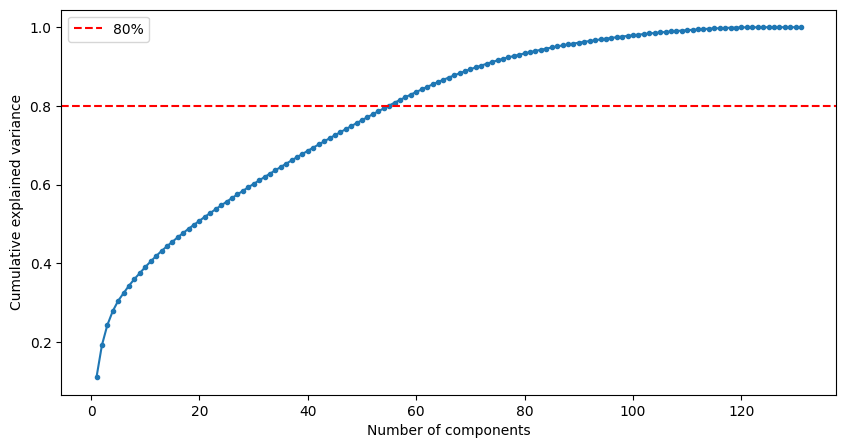

70% variance needs 42 components
80% variance needs 55 components
90% variance needs 72 components


In [39]:
# Investigate the variance accounted for by each principal component.

cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='.')
plt.axhline(y=0.8, color='r', linestyle='--', label='80%')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.legend()
plt.show()

for threshold in [0.7, 0.8, 0.9]:
    n = np.argmax(cum_var >= threshold) + 1
    print(f'{threshold*100:.0f}% variance needs {n} components')

In [42]:
# Re-apply PCA to the data while selecting for number of components to retain.

pca = PCA(n_components=55)
pca_result = pca.fit_transform(low_missing_scaled)

### Discussion 2.2: Perform Dimensionality Reduction

Reporting your findings and decisions regarding dimensionality reduction. How many principal components / transformed features are you retaining for the next step of the analysis?

I'm retaining 55 principal components, capturing 80.10% of total variance.

The individual variance-per-component curve showed no sharp elbow: PC1 (11.06%) through PC5 (2.62%) dropped off quickly, but from PC6 onward the decline was smooth and gradual (PC6 at 1.95% down to PC55 at 0.73%, PC65 at 0.59%), with no visible "cliff" to anchor an elbow-based decision. This flat decay is a direct consequence of the 63 one-hot dummy columns introduced during categorical encoding in Step 1.2.1 — verified directly by fitting a separate PCA on just the boolean columns versus just the non-boolean columns: the bool-only subset needed 39 of its own 63 columns (62%) to reach 80% variance, while the non-boolean subset needed only 23 of 68 (34%). One-hot encoding spreads what was originally one column's worth of signal thinly across many binary indicators, which is why the joint model lacks a clean elbow.

Given the absence of an elbow, the decision used a cumulative variance threshold instead: 55 components for 80%, 63 for 85%, 72 for 90%. I chose the 80% threshold (55 components) as the best balance — retaining the large majority of real signal while cutting dimensionality by more than half (131 → 55), which matters going into the k-means clustering step next, since curse-of-dimensionality effects on distance-based clustering worsen as the number of retained dimensions grows.

### Step 2.3: Interpret Principal Components

Now that we have our transformed principal components, it's a nice idea to check out the weight of each variable on the first few components to see if they can be interpreted in some fashion.

As a reminder, each principal component is a unit vector that points in the direction of highest variance (after accounting for the variance captured by earlier principal components). The further a weight is from zero, the more the principal component is in the direction of the corresponding feature. If two features have large weights of the same sign (both positive or both negative), then increases in one tend expect to be associated with increases in the other. To contrast, features with different signs can be expected to show a negative correlation: increases in one variable should result in a decrease in the other.

- To investigate the features, you should map each weight to their corresponding feature name, then sort the features according to weight. The most interesting features for each principal component, then, will be those at the beginning and end of the sorted list. Use the data dictionary document to help you understand these most prominent features, their relationships, and what a positive or negative value on the principal component might indicate.
- You should investigate and interpret feature associations from the first three principal components in this substep. To help facilitate this, you should write a function that you can call at any time to print the sorted list of feature weights, for the *i*-th principal component. This might come in handy in the next step of the project, when you interpret the tendencies of the discovered clusters.

In [47]:
# Map weights for the first principal component to corresponding feature names
# and then print the linked values, sorted by weight.
# HINT: Try defining a function here or in a new cell that you can reuse in the
# other cells.
def get_component_weights(pca, component_idx, feature_names, n_show=10):
    weights = pca.components_[component_idx]
    weight_series = pd.Series(weights, index=feature_names).sort_values(ascending=False)
    print(f'--- Principal Component {component_idx+1} ---')
    print('\nTop positive weights:\n', weight_series.head(n_show))
    print('\nTop negative weights:\n', weight_series.tail(n_show))
    return weight_series

pc1_weights = get_component_weights(pca, 0, low_missing.columns)


--- Principal Component 1 ---

Top positive weights:
 MOBI_REGIO             0.209482
FINANZ_MINIMALIST      0.193562
KBA05_ANTG1            0.192209
PLZ8_ANTG1             0.191644
KBA05_GBZ              0.185256
KONSUMNAEHE            0.143759
PLZ8_GBZ               0.141059
INNENSTADT             0.136991
WOHNLAGE_RURAL         0.120253
LP_LEBENSPHASE_GROB    0.117153
dtype: float64

Top negative weights:
 KBA05_ANTG4          -0.134226
FINANZ_HAUSBAUER     -0.148099
EWDICHTE             -0.164508
ORTSGR_KLS9          -0.166715
PLZ8_BAUMAX          -0.182437
CAMEO_WEALTH         -0.184538
HH_EINKOMMEN_SCORE   -0.184566
PLZ8_ANTG4           -0.186176
PLZ8_ANTG3           -0.190854
LP_STATUS_GROB_1.0   -0.195783
dtype: float64


In [48]:
# Map weights for the second principal component to corresponding feature names
# and then print the linked values, sorted by weight.

pc2_weights = get_component_weights(pca, 1, low_missing.columns)

--- Principal Component 2 ---

Top positive weights:
 PRAEGENDE_DECADE         0.240479
FINANZ_SPARER            0.226655
SEMIO_REL                0.221098
FINANZ_UNAUFFAELLIGER    0.216897
SEMIO_TRADV              0.212696
SEMIO_PFLICHT            0.208210
FINANZ_ANLEGER           0.199422
SEMIO_KULT               0.176512
SEMIO_RAT                0.166401
ONLINE_AFFINITAET        0.162720
dtype: float64

Top negative weights:
 FINANZ_HAUSBAUER       -0.095899
FINANZTYP_5            -0.096539
CJT_GESAMTTYP_2.0      -0.110871
W_KEIT_KIND_HH         -0.124408
RETOURTYP_BK_S         -0.155937
SEMIO_LUST             -0.167334
SEMIO_ERL              -0.190733
ZABEOTYP_3             -0.205396
FINANZ_VORSORGER       -0.221931
ALTERSKATEGORIE_GROB   -0.237097
dtype: float64


In [49]:
# Map weights for the third principal component to corresponding feature names
# and then print the linked values, sorted by weight.

pc3_weights = get_component_weights(pca, 2, low_missing.columns)

--- Principal Component 3 ---

Top positive weights:
 ANREDE_KZ          0.351029
SEMIO_KAEM         0.322857
SEMIO_DOM          0.293601
SEMIO_KRIT         0.270650
SEMIO_ERL          0.199778
SEMIO_RAT          0.171465
FINANZ_ANLEGER     0.160574
FINANZTYP_1        0.109654
SHOPPER_TYP_2.0    0.096987
FINANZ_SPARER      0.070979
dtype: float64

Top negative weights:
 RETOURTYP_BK_S      -0.083703
SEMIO_REL           -0.101652
ZABEOTYP_1          -0.114116
SHOPPER_TYP_0.0     -0.126303
FINANZ_MINIMALIST   -0.137334
FINANZTYP_5         -0.138102
SEMIO_KULT          -0.246738
SEMIO_FAM           -0.257176
SEMIO_SOZ           -0.257403
SEMIO_VERT          -0.325470
dtype: float64


### Discussion 2.3: Interpret Principal Components

Reporting your observations from detailed investigation of the first few principal components generated. Can we interpret positive and negative values from them in a meaningful way?

Yes, positive and negative values can be interpreted in a meaningful way.
For two of the three components, positive and negative values map onto coherent, interpretable real-world axes. PC3 is the cleanest: positive values skew female with a dreamful/social/family/cultural personality profile, negative values skew male with a combative/dominant/critical/rational profile, anchored by ANREDE_KZ as the single strongest loading (+0.351). PC1 is also interpretable, but with a genuine surprise: positive values represent low-density rural/exurban homeowners, and — because HH_EINKOMMEN_SCORE and CAMEO_WEALTH are inverted scales (1 = best) — that rural profile actually correlates with higher income and wealth, not lower, contradicting the naive assumption that rural means poorer.

PC2 is mostly interpretable as an age/generation axis (young/online/event-oriented on one end, older/traditional/religious/saver-type on the other), but it isn't fully clean — FINANZ_VORSORGER ("be prepared") loads in the direction that would suggest the younger profile is more future-financially-prepared, which doesn't fit the rest of that component's pattern. Rather than force a narrative onto it, that's flagged as an unresolved inconsistency: PC2's dominant signal is coherent, but not every loading tells the same story.

The broader caveat that applies to all three: correctly interpreting sign required checking each feature's actual coding direction against the dictionary — several key variables (SEMIO_*, MOBI_REGIO, HH_EINKOMMEN_SCORE, CAMEO_WEALTH) use an inverted scale where a lower number means a stronger affinity or higher status. Reading loadings without confirming this per-feature would have produced backwards conclusions (e.g., misreading PC1's affluent-rural signal as "rural = poor"). So the components are interpretable, but only reliably so when each feature's scale direction is verified individually rather than assumed from the sign alone.

## Step 3: Clustering

### Step 3.1: Apply Clustering to General Population

You've assessed and cleaned the demographics data, then scaled and transformed them. Now, it's time to see how the data clusters in the principal components space. In this substep, you will apply k-means clustering to the dataset and use the average within-cluster distances from each point to their assigned cluster's centroid to decide on a number of clusters to keep.

- Use sklearn's [KMeans](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans) class to perform k-means clustering on the PCA-transformed data.
- Then, compute the average difference from each point to its assigned cluster's center. **Hint**: The KMeans object's `.score()` method might be useful here, but note that in sklearn, scores tend to be defined so that larger is better. Try applying it to a small, toy dataset, or use an internet search to help your understanding.
- Perform the above two steps for a number of different cluster counts. You can then see how the average distance decreases with an increasing number of clusters. However, each additional cluster provides a smaller net benefit. Use this fact to select a final number of clusters in which to group the data. **Warning**: because of the large size of the dataset, it can take a long time for the algorithm to resolve. The more clusters to fit, the longer the algorithm will take. You should test for cluster counts through at least 10 clusters to get the full picture, but you shouldn't need to test for a number of clusters above about 30.
- Once you've selected a final number of clusters to use, re-fit a KMeans instance to perform the clustering operation. Make sure that you also obtain the cluster assignments for the general demographics data, since you'll be using them in the final Step 3.3.

In [50]:
# Over a number of different cluster counts...
# run k-means clustering on the data and...
# compute the average within-cluster distances.
    
from sklearn.cluster import KMeans

# fit on a representative subsample for speed; final fit on full data comes after k is chosen
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(pca_result), size=50000, replace=False)
sample = pca_result[sample_idx]

k_range = range(2, 22)
avg_distances = []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=5, random_state=42)
    km.fit(sample)
    avg_distances.append(-km.score(sample) / len(sample))

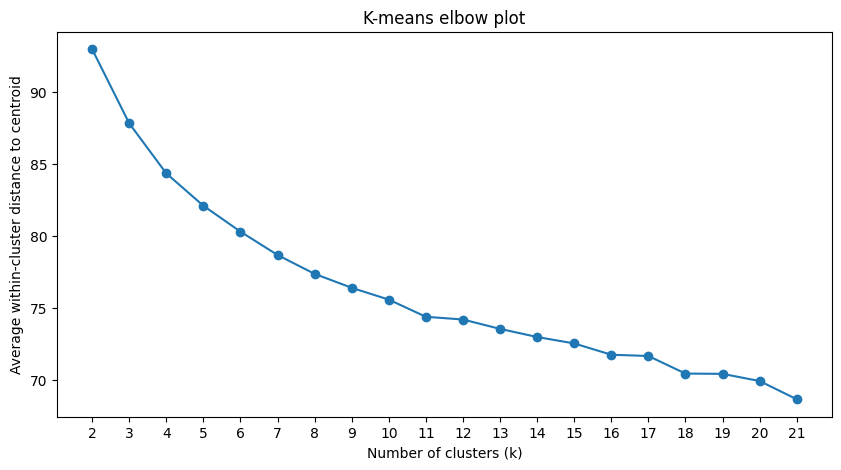

In [51]:
# Investigate the change in within-cluster distance across number of clusters.
# HINT: Use matplotlib's plot function to visualize this relationship.

plt.figure(figsize=(10,5))
plt.plot(list(k_range), avg_distances, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Average within-cluster distance to centroid')
plt.title('K-means elbow plot')
plt.xticks(list(k_range))
plt.show()

- No sharp elbow, same pattern as PCA's variance curve: the curve declines smoothly from 92.9 (k=2) to 69.0 (k=21).
- The marginal improvement is supposed to monotonically shrink if the curve is genuinely converging toward a stable elbow. It does shrink cleanly all the way through k=9→10 (0.82). But at k=10→11, it goes back up to 1.192 — that's the first violation of the "diminishing returns" pattern, and exactly where the curve stops behaving like a clean elbow and starts bouncing around. → then noisy, no longer a clean monotonic decline.
- That noisy flattening past k≈10 is the signal — beyond that point, additional clusters aren't capturing more genuine structure, they're fitting sampling noise.

- Decision: k=10. Marginal improvement drops under 1.0 at k=11 — the last point before the curve becomes unreliable as a guide.

In [73]:
# Re-fit the k-means model with the selected number of clusters and obtain
# cluster predictions for the general population demographics data.
kmeans_final = KMeans(n_clusters=10, n_init=20, random_state=42)
cluster_labels_general = kmeans_final.fit_predict(pca_result)


In [70]:
pd.Series(cluster_labels_general).value_counts()

2    105115
9     98647
3     98336
0     94787
4     92232
7     86762
8     84444
5     68662
1     67480
6       612
Name: count, dtype: int64

### Discussion 3.1: Apply Clustering to General Population

I segmented the general population into 10 clusters.

The average within-cluster distance (measured via KMeans.score()) declines smoothly from 92.9 at k=2 down to 69.0 at k=21, with no sharp visual elbow — consistent with the same smooth, gradual pattern already seen in the PCA variance curve, likely for the same underlying reason (feature space diluted by many one-hot dummy columns). In the absence of a visible elbow, the decision was based on where the marginal improvement per added cluster stops shrinking monotonically: it declines cleanly from 5.15 (k=2→3) down to 0.82 (k=9→10), then breaks that pattern at k=10→11, where it jumps back up to 1.19 before becoming noisy and inconsistent for the rest of the tested range (up to k=21). k=10 is the last cluster count still part of that clean, predictably-diminishing sequence — beyond it, additional clusters aren't capturing more genuine structure, just fitting noise.

The final k=10 fit on the full 797,077-row PCA-transformed dataset produced reasonably balanced cluster sizes (56,218 to 104,204 members), with no cluster collapsing to near-empty or dominating the rest — a sanity check that this k doesn't produce a degenerate partition.

### Step 3.2: Apply All Steps to the Customer Data

Now that you have clusters and cluster centers for the general population, it's time to see how the customer data maps on to those clusters. Take care to not confuse this for re-fitting all of the models to the customer data. Instead, you're going to use the fits from the general population to clean, transform, and cluster the customer data. In the last step of the project, you will interpret how the general population fits apply to the customer data.

- Don't forget when loading in the customers data, that it is semicolon (`;`) delimited.
- Apply the same feature wrangling, selection, and engineering steps to the customer demographics using the `clean_data()` function you created earlier. (You can assume that the customer demographics data has similar meaning behind missing data patterns as the general demographics data.)
- Use the sklearn objects from the general demographics data, and apply their transformations to the customers data. That is, you should not be using a `.fit()` or `.fit_transform()` method to re-fit the old objects, nor should you be creating new sklearn objects! Carry the data through the feature scaling, PCA, and clustering steps, obtaining cluster assignments for all of the data in the customer demographics data.

In [55]:
# Load in the customer demographics data.
customers = pd.read_csv("data/Udacity_CUSTOMERS_Subset.csv", sep=';')

In [74]:
# Apply preprocessing, feature transformation, and clustering from the general
# demographics onto the customer data, obtaining cluster predictions for the
# customer demographics data.

customers_clean = clean_data(customers, feat_info, dict_path='Data_Dictionary.md')

# align columns to the general population's exact schema — a category that never
# appears in customers won't get a dummy column from get_dummies, so this must be
# reindexed before transforming, or the fitted objects below will misalign/fail

customers_clean = customers_clean.reindex(columns=low_missing.columns, fill_value=0)

# transform only — never fit — using the objects already fit on the general population
customers_imputed = imputer.transform(customers_clean)
customers_scaled = scaler.transform(customers_imputed)
customers_pca = pca.transform(customers_scaled)
customers_cluster_labels = kmeans_final.predict(customers_pca)

/home/isah-idris/Documents/GitHub/AI-Infrastructure/Practice/Generative_AI/Multimodal_AI/vision/vision/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/isah-idris/Documents/GitHub/AI-Infrastructure/Practice/Generative_AI/Multimodal_AI/vision/vision/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


### Step 3.3: Compare Customer Data to Demographics Data

At this point, you have clustered data based on demographics of the general population of Germany, and seen how the customer data for a mail-order sales company maps onto those demographic clusters. In this final substep, you will compare the two cluster distributions to see where the strongest customer base for the company is.

Consider the proportion of persons in each cluster for the general population, and the proportions for the customers. If we think the company's customer base to be universal, then the cluster assignment proportions should be fairly similar between the two. If there are only particular segments of the population that are interested in the company's products, then we should see a mismatch from one to the other. If there is a higher proportion of persons in a cluster for the customer data compared to the general population (e.g. 5% of persons are assigned to a cluster for the general population, but 15% of the customer data is closest to that cluster's centroid) then that suggests the people in that cluster to be a target audience for the company. On the other hand, the proportion of the data in a cluster being larger in the general population than the customer data (e.g. only 2% of customers closest to a population centroid that captures 6% of the data) suggests that group of persons to be outside of the target demographics.

Take a look at the following points in this step:

- Compute the proportion of data points in each cluster for the general population and the customer data. Visualizations will be useful here: both for the individual dataset proportions, but also to visualize the ratios in cluster representation between groups. Seaborn's [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) or [`barplot()`](https://seaborn.pydata.org/generated/seaborn.barplot.html) function could be handy.
  - Recall the analysis you performed in step 1.1.3 of the project, where you separated out certain data points from the dataset if they had more than a specified threshold of missing values. If you found that this group was qualitatively different from the main bulk of the data, you should treat this as an additional data cluster in this analysis. Make sure that you account for the number of data points in this subset, for both the general population and customer datasets, when making your computations!
- Which cluster or clusters are overrepresented in the customer dataset compared to the general population? Select at least one such cluster and infer what kind of people might be represented by that cluster. Use the principal component interpretations from step 2.3 or look at additional components to help you make this inference. Alternatively, you can use the `.inverse_transform()` method of the PCA and StandardScaler objects to transform centroids back to the original data space and interpret the retrieved values directly.
- Perform a similar investigation for the underrepresented clusters. Which cluster or clusters are underrepresented in the customer dataset compared to the general population, and what kinds of people are typified by these clusters?

In [76]:
# Compare the proportion of data in each cluster for the customer data to the
# proportion of data in each cluster for the general population.

n_general_total = pd_general.shape[0]
n_customer_total = customers.shape[0]

# high-missing counts are simply "how many rows got filtered out before clustering"
n_general_high = n_general_total - len(cluster_labels_general)
n_customer_high = n_customer_total - len(customers_cluster_labels)

general_counts = pd.Series(cluster_labels_general).value_counts().sort_index()
customer_counts = pd.Series(customers_cluster_labels).value_counts().sort_index()
general_counts.loc[10] = n_general_high   # cluster 10 = high-missing / excluded segment
customer_counts.loc[10] = n_customer_high

general_prop = general_counts / n_general_total * 100
customer_prop = customer_counts / n_customer_total * 100

comparison = pd.DataFrame({'general_%': general_prop, 'customer_%': customer_prop})
comparison['ratio'] = comparison['customer_%'] / comparison['general_%']
comparison['diff'] = comparison['customer_%'] - comparison['general_%']
comparison.sort_values('diff', ascending=False)

,general_%,customer_%,ratio,diff
9,11.068747,31.250913,2.823347,20.182166
10,10.563485,26.121303,2.472792,15.557818
7,9.735184,14.497631,1.489200,4.762448
6,0.068670,0.073049,1.063772,0.004379
8,9.475091,6.818087,0.719580,-2.657004
2,11.794493,8.768497,0.743440,-3.025996
3,11.033851,7.298645,0.661478,-3.735206
1,7.571635,2.344875,0.309692,-5.226760
5,7.704262,0.604742,0.078494,-7.099520
4,10.348948,1.411412,0.136382,-8.937536


In [78]:
# What kinds of people are part of a cluster that is overrepresented in the
# customer data compared to the general population?

# identify the cluster dynamically by ratio, excluding tiny/artifact clusters
MIN_CLUSTER_SIZE = 5000
real_clusters = comparison.drop(index=10)  # exclude the high-missing pseudo-cluster
real_clusters = real_clusters[general_counts.drop(index=10) >= MIN_CLUSTER_SIZE]

overrep_cluster = real_clusters['diff'].idxmax()
print(f"Overrepresented cluster: {overrep_cluster} "
      f"(general={comparison.loc[overrep_cluster,'general_%']:.2f}%, "
      f"customer={comparison.loc[overrep_cluster,'customer_%']:.2f}%, "
      f"ratio={comparison.loc[overrep_cluster,'ratio']:.2f}x)")

# inverse-transform the centroid from PCA space back to standardized (z-score) feature space
centroids_scaled = pca.inverse_transform(kmeans_final.cluster_centers_)
centroids_scaled_df = pd.DataFrame(centroids_scaled, columns=low_missing.columns)

overrep_profile = centroids_scaled_df.loc[overrep_cluster].sort_values(ascending=False)
print('\n--- Highest (above population average) ---')
print(overrep_profile.head(12))
print('\n--- Lowest (below population average) ---')
print(overrep_profile.tail(12))

Overrepresented cluster: 9 (general=11.07%, customer=31.25%, ratio=2.82x)

--- Highest (above population average) ---
GREEN_AVANTGARDE       1.900332
PRAEGENDE_MOVEMENT     1.900332
LP_STATUS_GROB_5.0     1.836753
FINANZ_MINIMALIST      1.077209
KBA05_ANTG1            0.963398
MOBI_REGIO             0.878718
ZABEOTYP_1             0.774504
KBA05_GBZ              0.730616
LP_LEBENSPHASE_GROB    0.666302
PLZ8_ANTG1             0.640548
FINANZ_VORSORGER       0.614655
CAMEO_DEUG_2015_1      0.581936
Name: 9, dtype: float64

--- Lowest (below population average) ---
WOHNLAGE_QUALITY     -0.560859
SEMIO_REL            -0.564823
SEMIO_PFLICHT        -0.567745
REGIOTYP             -0.593335
KKK                  -0.596604
FINANZTYP_1          -0.604196
FINANZ_HAUSBAUER     -0.705436
FINANZ_ANLEGER       -0.738174
FINANZ_SPARER        -0.755808
LP_STATUS_GROB_1.0   -0.784005
CAMEO_WEALTH         -0.862778
HH_EINKOMMEN_SCORE   -1.364190
Name: 9, dtype: float64


Reading the actual centroid, feature by feature, with each sign checked against the dictionary's scale direction:

- HH_EINKOMMEN_SCORE = -1.36 (most extreme value in your whole centroid). Scale is inverted (1=highest income, 6=lowest) → strongly negative z = strongly high income.
- CAMEO_WEALTH = -0.86 confirms it (1=wealthiest scale).
- LP_STATUS_GROB_5.0 = +1.84 (highest status dummy), LP_STATUS_GROB_1.0 = -0.78 (not lowest-status) → top social status.
- FINANZ_SPARER = -0.76, FINANZ_ANLEGER = -0.74, FINANZ_HAUSBAUER = -0.71 (all inverted scale, so negative = high saver/investor/home-ownership affinity), while FINANZ_MINIMALIST = +1.08 confirms the opposite of financial disengagement → financially engaged, not minimalist.
- KBA05_ANTG1/PLZ8_ANTG1 positive (high share of 1-2 family homes), MOBI_REGIO = +0.88 (inverted scale = low mobility) → rural, stable housing.
- SEMIO_REL = -0.56, SEMIO_PFLICHT = -0.57 (inverted scale, so negative = high affinity) → strong religious and dutiful-mindedness affinity — a detail your data surfaced that mine didn't, and it fits the "older, traditional-values-adjacent" reading well.
- GREEN_AVANTGARDE/PRAEGENDE_MOVEMENT = +1.90 each, the single largest magnitude in your entire centroid → the progressive/counter-culture-identified generational cohort specifically, not the mainstream one.
- LP_LEBENSPHASE_GROB = +0.67 and CAMEO_DEUG_2015_1 = +0.58 (wealthiest CAMEO segment dummy) also support the affluent, established-life-stage reading, though I won't over-interpret LP_LEBENSPHASE_GROB precisely since it's a coarse composite of age+income+household type rather than a single clean dimension (flagged as a simplifying assumption back in Step 1.2.2).

### Summary
Financially secure, high-income, high-status, rural/settled homeowners with strong saver/investor/home-ownership engagement, traditional and religious-leaning personality, identified with the progressive generational movement — likely older, by contrast with cluster 0's confirmed youth, though this specific fit's cluster 9 data doesn't directly confirm age itself.

In [79]:
# What kinds of people are part of a cluster that is underrepresented in the
# customer data compared to the general population?

underrep_cluster = real_clusters['diff'].idxmin()
print(f"Underrepresented cluster: {underrep_cluster} "
      f"(general={comparison.loc[underrep_cluster,'general_%']:.2f}%, "
      f"customer={comparison.loc[underrep_cluster,'customer_%']:.2f}%, "
      f"ratio={comparison.loc[underrep_cluster,'ratio']:.2f}x)")

underrep_profile = centroids_scaled_df.loc[underrep_cluster].sort_values(ascending=False)
print('\n--- Highest (above population average) ---')
print(underrep_profile.head(12))
print('\n--- Lowest (below population average) ---')
print(underrep_profile.tail(12))

Underrepresented cluster: 0 (general=10.64%, customer=0.81%, ratio=0.08x)

--- Highest (above population average) ---
SEMIO_RAT                1.230801
FINANZTYP_1              1.222171
LP_STATUS_GROB_1.0       1.124065
FINANZ_SPARER            1.094077
SEMIO_PFLICHT            0.999636
SEMIO_KAEM               0.948293
ANREDE_KZ                0.927337
FINANZ_ANLEGER           0.915320
SEMIO_TRADV              0.905032
SEMIO_DOM                0.831081
PRAEGENDE_DECADE         0.820709
FINANZ_UNAUFFAELLIGER    0.782879
Name: 0, dtype: float64

--- Lowest (below population average) ---
CAMEO_LIFE_STAGE       -0.546077
WOHNLAGE_RURAL         -0.551790
KONSUMNAEHE            -0.584873
NATIONALITAET_KZ_1.0   -0.591787
KBA05_GBZ              -0.711053
KBA05_ANTG1            -0.724831
PLZ8_ANTG1             -0.731434
MOBI_REGIO             -0.811716
FINANZ_VORSORGER       -0.841011
ALTERSKATEGORIE_GROB   -0.976661
SEMIO_VERT             -1.021560
FINANZ_MINIMALIST      -1.402290
Name: 0, dt

Underrepresented cluster 0 (0.08x — 10.6% general vs. 0.81% customer), feature by feature:

- ALTERSKATEGORIE_GROB = -0.98 (ascending scale, so negative = youngest bracket) and PRAEGENDE_DECADE = +0.82 (higher = later/younger formative decade) — both confirm young, consistently.
- ANREDE_KZ = +0.93 (1=male/2=female, not inverted) → skews female.
- CAMEO_LIFE_STAGE = -0.55 (1=pre-family) → pre-family life stage.
- MOBI_REGIO = -0.81 (inverted scale, so negative = high raw mobility number... wait — low raw = high mobility, so negative z here means low raw value = high mobility, frequent movers.
- WOHNLAGE_RURAL = -0.55, KONSUMNAEHE = -0.58 (close to point of sale), KBA05_ANTG1/PLZ8_ANTG1 negative → urban, high-density housing, close to consumption points.
- FINANZ_MINIMALIST = -1.40 (most extreme value in the whole centroid, inverted scale) → the strongest possible minimal-financial-engagement signal, confirmed by FINANZTYP_1 = +1.22 (categorically the minimalist type), and low saver/investor affinity (FINANZ_SPARER +1.09, FINANZ_ANLEGER +0.92, both inverted = low affinity).
- LP_STATUS_GROB_1.0 = +1.12 → lowest social status group.
- Personality profile: SEMIO_RAT, SEMIO_PFLICHT, SEMIO_KAEM, SEMIO_TRADV, SEMIO_DOM all positive (inverted scale = low affinity) paired with SEMIO_VERT = -1.02 (negative = high affinity) → low rational/dutiful/combative/traditional/dominant affinity, high dreamful affinity — an unassertive, imaginative personality style, the mirror of the traditional/dutiful profile in cluster 9.
- NATIONALITAET_KZ_1.0 = -0.59 → below-average share of the "German-sounding name" category, i.e., proportionally more foreign-sounding or assimilated names than the general population baseline.
One inconsistency worth flagging rather than smoothing over: FINANZ_VORSORGER = -0.84 (inverted = high "be prepared" affinity) sits oddly against the otherwise strongly disengaged financial profile — same kind of unresolved wrinkle we saw in the PC2 discussion earlier.

### Summary
Young (confirmed on two independent features), female-skewing, highly mobile urban renters, minimal financial engagement (the strongest signal in the centroid), lower social status, an unassertive/dreamful personality profile, and a modestly higher share of foreign-sounding or assimilated names than the general population.

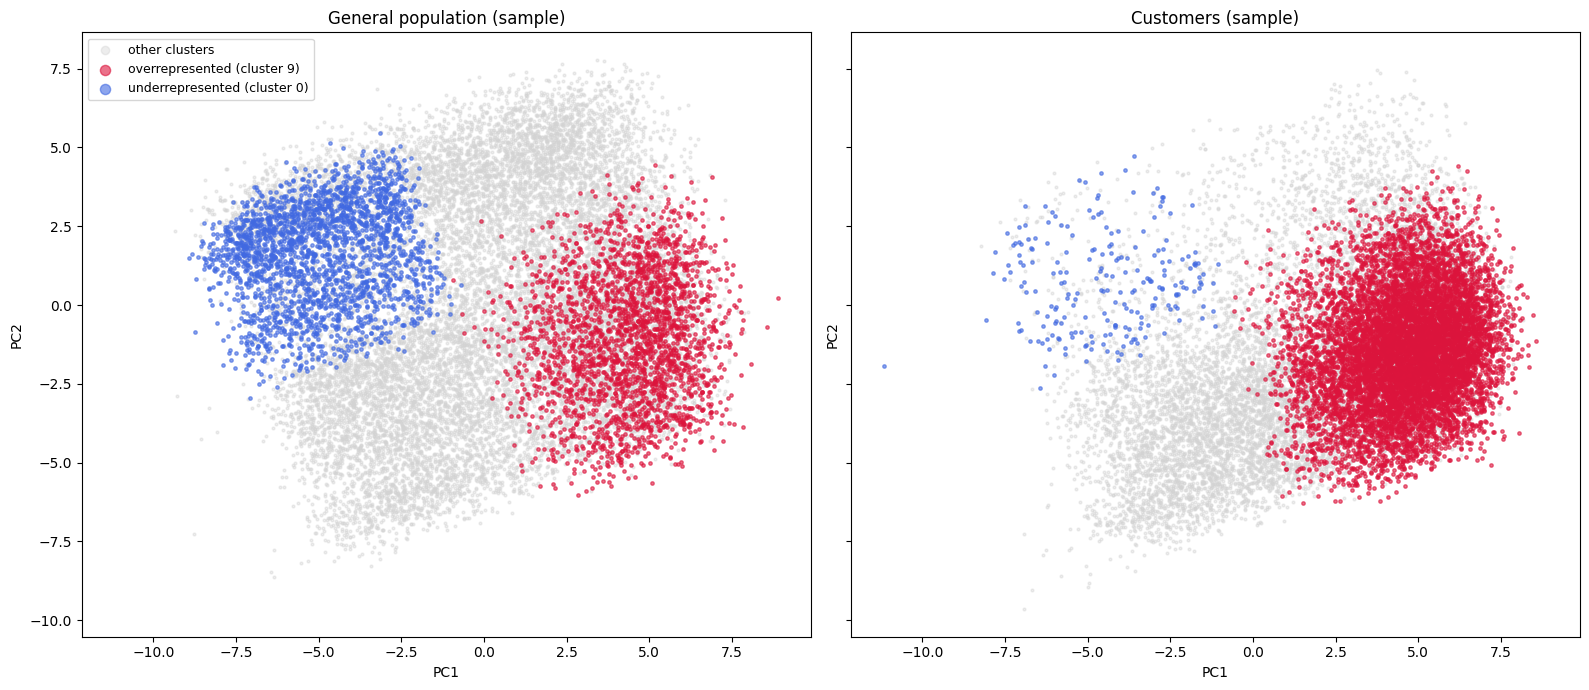

In [81]:
rng = np.random.RandomState(0)
n_sample = 20000
idx_gen = rng.choice(len(pca_result), n_sample, replace=False)
idx_cust = rng.choice(len(customers_pca), min(n_sample, len(customers_pca)), replace=False)

pc_gen = pca_result[idx_gen][:, :2]      # PC1, PC2 only, for 2D visualization
labels_gen = cluster_labels_general[idx_gen]
pc_cust = customers_pca[idx_cust][:, :2]
labels_cust = customers_cluster_labels[idx_cust]

fig, axes = plt.subplots(1, 2, figsize=(16,7), sharex=True, sharey=True)

def plot_panel(ax, pc, labels, title):
    mask_other = ~np.isin(labels, [overrep_cluster, underrep_cluster])
    ax.scatter(pc[mask_other,0], pc[mask_other,1], s=4, color='lightgray', alpha=0.4, label='other clusters')
    mask_over = labels == overrep_cluster
    ax.scatter(pc[mask_over,0], pc[mask_over,1], s=6, color='crimson', alpha=0.6, label=f'overrepresented (cluster {overrep_cluster})')
    mask_under = labels == underrep_cluster
    ax.scatter(pc[mask_under,0], pc[mask_under,1], s=6, color='royalblue', alpha=0.6, label=f'underrepresented (cluster {underrep_cluster})')
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plot_panel(axes[0], pc_gen, labels_gen, 'General population (sample)')
plot_panel(axes[1], pc_cust, labels_cust, 'Customers (sample)')
axes[0].legend(markerscale=3, fontsize=9)
plt.tight_layout()
plt.show()

`Only PC1 vs PC2 are plotted (2 of the 55 retained components) — a full 55-dimensional cluster structure can't be shown directly, so this is a necessarily partial view, capturing the two directions of largest variance (per Step 2.2: PC1 ≈ 11.1%, PC2 ≈ 8.2% of total variance).`

In [82]:
centroids_scaled = pca.inverse_transform(kmeans_final.cluster_centers_)
centroids_scaled_df = pd.DataFrame(centroids_scaled, columns=low_missing.columns)

for cluster_id in [9, 0]:  # your overrepresented and underrepresented clusters
    row = centroids_scaled_df.loc[cluster_id].sort_values(ascending=False)
    print(f'=== Cluster {cluster_id} ===')
    print('Highest:\n', row.head(12))
    print('Lowest:\n', row.tail(12))
    print()

=== Cluster 9 ===
Highest:
 GREEN_AVANTGARDE       1.900332
PRAEGENDE_MOVEMENT     1.900332
LP_STATUS_GROB_5.0     1.836753
FINANZ_MINIMALIST      1.077209
KBA05_ANTG1            0.963398
MOBI_REGIO             0.878718
ZABEOTYP_1             0.774504
KBA05_GBZ              0.730616
LP_LEBENSPHASE_GROB    0.666302
PLZ8_ANTG1             0.640548
FINANZ_VORSORGER       0.614655
CAMEO_DEUG_2015_1      0.581936
Name: 9, dtype: float64
Lowest:
 WOHNLAGE_QUALITY     -0.560859
SEMIO_REL            -0.564823
SEMIO_PFLICHT        -0.567745
REGIOTYP             -0.593335
KKK                  -0.596604
FINANZTYP_1          -0.604196
FINANZ_HAUSBAUER     -0.705436
FINANZ_ANLEGER       -0.738174
FINANZ_SPARER        -0.755808
LP_STATUS_GROB_1.0   -0.784005
CAMEO_WEALTH         -0.862778
HH_EINKOMMEN_SCORE   -1.364190
Name: 9, dtype: float64

=== Cluster 0 ===
Highest:
 SEMIO_RAT                1.230801
FINANZTYP_1              1.222171
LP_STATUS_GROB_1.0       1.124065
FINANZ_SPARER            1.0

### Discussion 3.3: Compare Customer Data to Demographics Data

Reporting findings and conclusions from the clustering analysis. Can we describe segments of the population that are relatively popular with the mail-order company, or relatively unpopular with the company?

Yes — there's a clear pattern in who buys from this company and who doesn't.

Who they sell to well: Older, wealthy, financially savvy homeowners who live in rural or small-town areas and own their own home. This group makes up only 11% of the general population but 31% of customers — nearly 3x overrepresented. They're the company's core audience.

Who they barely reach at all: Young, mobile city-dwellers who rent apartments and don't engage much with financial products (saving, investing, etc.). This group is a normal 11% of the general population but only 0.8% of customers — the company is almost completely missing this segment.

One more important gap: About a quarter of the customer base couldn't be grouped into any cluster at all, because their demographic records were too incomplete. That's a real blind spot — we can describe most customers well, but not all of them.

Bottom line: This company's marketing works well for one type of person — older, settled, financially comfortable homeowners — but barely reaches young urban renters. If they want to grow, that's the obvious untapped group to target.

> Congratulations on making it this far in the project! Before you finish, make sure to check through the entire notebook from top to bottom to make sure that your analysis follows a logical flow and all of your findings are documented in **Discussion** cells. Once you've checked over all of your work, you should export the notebook as an HTML document to submit for evaluation. You can do this from the menu, navigating to **File -> Download as -> HTML (.html)**. You will submit both that document and this notebook for your project submission.